In [13]:
import astropy.units as u
import astropy.constants as const
import numpy as np
import scipy.integrate as integrate
import pandas as pd
import matplotlib.pyplot as plt

#cosmologial constants from the planck misison https://arxiv.org/pdf/1807.06209
cosm_planck={'H_0': 67.37*(u.km/u.s/u.Mpc), 'Omega_m': 0.315, 'Omega_v': 1-0.315, 'Omega_r': 0, 'Omega_k': 0}


Implement functions to calculate various cosmological values given redshift $z$, $H_0$, $\Omega_m$, etc.

- light travel time
- comoving radial distance
- luminosity distance $D_L$



In [74]:

# returns the intensity of a source at redshift z as a factor of the source power
def J_factor(cosm, z):
    return 1/(4*np.pi * (1+z)**2 * r(cosm,z)**2)

J_factor_np = np.frompyfunc(J_factor, 2, 1)

# returns the luminosity distance of a source at redshift z
# by definition this is the distance at which a flat euclidean universe would produce 
# the same intensity factor
def D_L(cosm, z):
    return (1/(4*np.pi*J_factor(cosm, z)))**(1/2)
D_L_np = np.frompyfunc(D_L, 2, 1)

# returns the radial distance of a source at redshift z
def r(cosm, z):
    result = integrate.quad(lambda x: f(cosm, x), 0, z)
    return (const.c/cosm['H_0']*result[0]).to(u.Mpc)
r_np = np.frompyfunc(r, 2, 1)

# the integrand used in the radial distance function
def f(cosm, z):
    return 1/(cosm['Omega_m']*(1+z)**3 + cosm['Omega_r']*(1+z)**4 + cosm['Omega_v'] + cosm['Omega_k']*(1+z)**2)**(1/2)


z = np.arange(0.0, 1.6, 0.1)


cosm={'H_0': 67.3*(u.km/u.s/u.Mpc), 'Omega_m': .3, 'Omega_v': .7, 'Omega_r': 0, 'Omega_k': 0}
df=pd.DataFrame({"z":z, "r":r_np(cosm, z), "D_L":D_L_np(cosm, z)})
df.style.hide(axis='index')
print()
display(df)


/home/adamarthurryan/micromamba/envs/jupyter/lib/python3.13/site-packages/astropy/units/quantity.py:659: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


,z,r,D_L
0,0.0,0.0 Mpc,0.0 Mpc
1,0.1,435.24240912242976 Mpc,478.76665003467275 Mpc
2,0.2,849.4892531028802 Mpc,1019.3871037234562 Mpc
3,0.3,1242.3147233293591 Mpc,1615.009140328167 Mpc
4,0.4,1613.7924763276962 Mpc,2259.3094668587746 Mpc
5,0.5,1964.3949140466332 Mpc,2946.59237106995 Mpc
6,0.6,2294.8876653340208 Mpc,3671.820264534433 Mpc
7,0.7,2606.232848565829 Mpc,4430.59584256191 Mpc
8,0.8,2899.5081064805127 Mpc,5219.114591664923 Mpc
9,0.9,3175.843424481144 Mpc,6034.102506514174 Mpc


Graph the observed supernova brightnesses vs what is predicted under various comological models

<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:25: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\L'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:25: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\L'
/tmp/ipykernel_48573/8642987.py:24: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(z,mu_flat, label="flat, $\Omega_m=1$")
/tmp/ipykernel_48573/8642987.py:25: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(z,mu_open, label="open, $\Omega_m=0.3$")
/tmp/ipykernel_48573/8642987.py:26: SyntaxWarning: invalid escape sequence '\L'
  plt.plot(z,mu_lambda_cdm, label="$\Lambda$CDM, $\Omega_m=0.3$, $\Omega_{vac}=0.7$")


<function matplotlib.pyplot.show(close=None, block=None)>

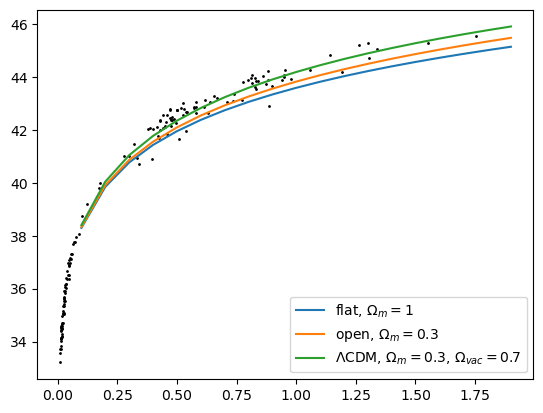

In [ ]:
#read in the sample
sn_df = pd.read_csv('./riese-et-al-2004.csv')
#filter to gold data points only
sn_df = sn_df[sn_df['sample']=='gold']

# return distance modulus for a given luminosity distance
def mu(D_L):
    return 5*np.log10(D_L.to(u.Mpc).value)+25
mu_np = np.frompyfunc(mu, 1, 1)

plt.plot(sn_df['z'],sn_df['mu_a_0'], "ko", markersize=1.0)

z = np.arange(0.1, 2.0, 0.1)

H_0 = 67.3*(u.km/u.s/u.Mpc)
cosm_flat_matter_dominated={'H_0': H_0, 'Omega_m': 1, 'Omega_v': 0, 'Omega_r': 0, 'Omega_k': 0}
cosm_open={'H_0': H_0, 'Omega_m': 0.3, 'Omega_v': 0, 'Omega_r': 0, 'Omega_k': 0.7}
cosm_lambda_cdm={'H_0': H_0, 'Omega_m': 0.3, 'Omega_v': 0.7, 'Omega_r': 0, 'Omega_k': 0}

mu_flat = mu_np(D_L_np(cosm_flat_matter_dominated, z))

mu_lambda_cdm = mu_np(D_L_np(cosm_lambda_cdm, z))


# this is not currently the correct value for an open universe, need to add the code
#mu_open = mu_np(D_L_np(cosm_open, z))

plt.plot(z,mu_flat, label="flat, $\Omega_m=1$")
#plt.plot(z,mu_open, label="open, $\Omega_m=0.3$")
plt.plot(z,mu_lambda_cdm, label="$\Lambda$CDM, $\Omega_m=0.3$, $\Omega_{vac}=0.7$")
plt.legend()
plt.show